### Differential Equations and Linear Algebra | Gilbert Strang | Solutions and Code by David A. Lee
### Chapter 8: Fourier and Laplace Transforms
#### Section 8.4: The Wave Equation 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MaxNLocator
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, animation_style, saveanim, neon_cmap

In [2]:
def style_ax3d(
    ax,
    xlabel='$x$',
    ylabel='$y$',
    zlabel='$z$',
    xlim=None,
    ylim=None,
    zlim=None,
    xticks=None,
    xticklabels=None,
    yticks=None,
    yticklabels=None,
    zticks=None,
    zticklabels=None,
    color=FG,
    *,
    label_fontsize=16,
    tick_fontsize=None,
    fontsize=None,
):
    """Axis titles vs tick numbers can use different font sizes.

    Legacy: if only ``fontsize`` is given, it applies to labels and ticks.
    """
    if fontsize is not None:
        label_fontsize = fontsize
        if tick_fontsize is None:
            tick_fontsize = fontsize
    if tick_fontsize is None:
        tick_fontsize = label_fontsize

    ax.set_xlabel(xlabel, color=color, fontsize=label_fontsize, labelpad=6)
    ax.set_ylabel(ylabel, color=color, fontsize=label_fontsize, labelpad=6)
    ax.set_zlabel(zlabel, color=color, fontsize=label_fontsize, labelpad=6)
    ax.tick_params(colors=color, labelsize=tick_fontsize)
    ax.minorticks_off()
    ax.grid(False)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    if zlim is not None:
        ax.set_zlim(zlim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels, color=color)
    if yticks is not None:
        ax.set_yticks(yticks)
    if yticklabels is not None:
        ax.set_yticklabels(yticklabels, color=color)
    if zticks is not None:
        ax.set_zticks(zticks)
    if zticklabels is not None:
        ax.set_zticklabels(zticklabels, color=color)
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(color)
    ax.yaxis.pane.set_edgecolor(color)
    ax.zaxis.pane.set_edgecolor(color)

Question 8.4.5

<>:26: SyntaxWarning: invalid escape sequence '\,'
<>:26: SyntaxWarning: invalid escape sequence '\,'
C:\Users\david\AppData\Local\Temp\ipykernel_41240\2323710260.py:26: SyntaxWarning: invalid escape sequence '\,'
  ax.set_ylabel('$u(x,\,t)$', fontsize=16)


saved chap8sec8.4ex5.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.4\chap8sec8.4ex5.pdf


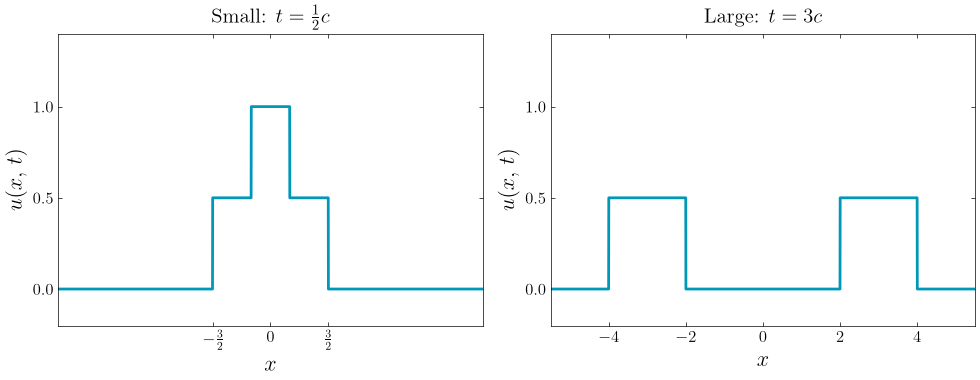

In [3]:
c = 1

def u0(x):
    return np.where(np.abs(x) <= 1, 1.0, 0.0)

def u(t, x):
    return 0.5 * u0(x + c*t) + 0.5 * u0(x - c*t)

x = np.linspace(-5.5, 5.5, 5000)
t_small = c / 2
t_large = 3*c


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

configs = [
    (t_small, C.cyan, r'Small:  $t = \frac{1}{2}c$',
     [-3/2, 0, 3/2], [r'$-\frac{3}{2}$', r'$0$', r'$\frac{3}{2}$']),
    (t_large, C.cyan, r'Large:  $t = 3c$',
     [-4, -2, 0, 2, 4], [r'$-4$', r'$-2$', r'$0$', r'$2$', r'$4$']),
]

for ax, (t_val, color, title, xticks, xlabels) in zip([ax1, ax2], configs):
    ax.plot(x, u(t_val, x), color=color, linewidth=2)
    ax.set_xlabel('$x$', fontsize=16)
    ax.set_ylabel('$u(x,\,t)$', fontsize=16)
    ax.set_title(title, fontsize=15, pad=8)
    ax.set_xlim(-5.5, 5.5)
    ax.set_ylim(-0.2, 1.4)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, fontsize=12)
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(labelsize=12)
    ax.minorticks_off()

fig.tight_layout()
savefig(fig, "chap8sec8.4ex5.pdf", bbox_inches='tight', pad_inches=0.3)
plt.show()

Question 8.4.12

saved chap8sec8.4ex12.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.4\chap8sec8.4ex12.pdf


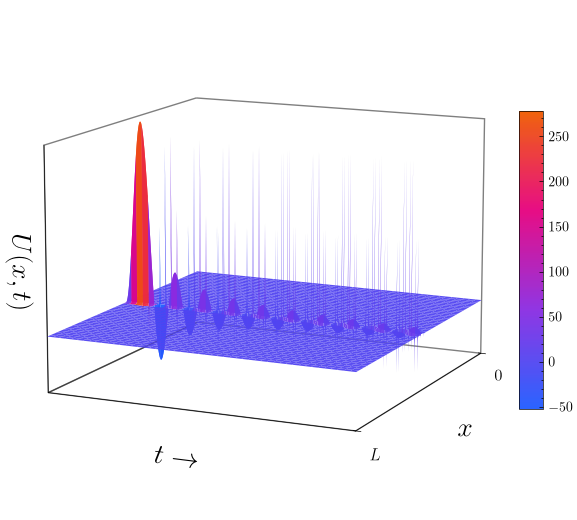

In [4]:
#%matplotlib widget
L = 1

x_min, x_max = 0, L
t_min, t_max = 0, 0.01
nx, nt = 1000, 1000  # grid resolution

c = 1 

def U(x, t):
    U = (2/L)*sum((-1)**(k+1)*np.sin((2*k-1)*np.pi*x/L)*np.cos((2*k-1)*np.pi*c*t/L) for k in range(1, 1000))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

# Optional: z-axis limits (set to None to auto-scale from Z) 
u_min, u_max = float(np.nanmin(u)), float(np.nanmax(u))


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

ax.set_xticks([x_min, x_max])
ax.set_xticklabels(['$0$', '$L$'])
ax.tick_params(axis='x', length=4, width=0.8)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap=neon_cmap(), linewidth=0, antialiased=True, alpha=0.95
)

style_ax3d(
    ax, xlabel='$x$', ylabel='$t \\rightarrow$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

ax.zaxis.labelpad = -10

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

# View orientation
ax.view_init(elev=12, azim=25)

fig.subplots_adjust(left=0.15, right=0.9, bottom=0.05, top=0.95)
savefig(fig, "chap8sec8.4ex12.pdf", bbox_inches='tight', pad_inches=0.3)
plt.show()

Question 8.4.13

saved chap8sec8.4ex13.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.4\chap8sec8.4ex13.pdf


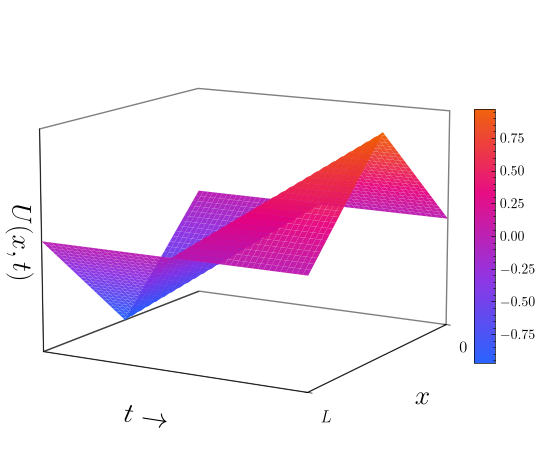

In [5]:
#%matplotlib widget
L = 1

x_min, x_max = 0, L
t_min, t_max = 0, 1
nx, nt = 1000, 1000  # grid resolution

c = 1 

def U(x, t):
    U = (8/np.pi**2)*sum((-1)**(k)/((2*k-1)**2)*np.sin((2*k-1)*np.pi*x/L)*np.cos((2*k-1)*np.pi*c*t/L) for k in range(1, 1000))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

u_min, u_max = float(np.nanmin(u)), float(np.nanmax(u))


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

ax.set_xticks([x_min, x_max])
ax.set_xticklabels(['$0$', '$L$'])
ax.tick_params(axis='x', length=4, width=0.8)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap=neon_cmap(), linewidth=0, antialiased=True, alpha=0.95
)

style_ax3d(
    ax, xlabel='$x$', ylabel='$t \\rightarrow$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

ax.zaxis.labelpad = -12

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

ax.view_init(elev=12, azim=30)

savefig(fig, "chap8sec8.4ex13.pdf", bbox_inches='tight', pad_inches=0.3)
plt.show()

Question 8.4.14

saved chap8sec8.4ex14.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.4\chap8sec8.4ex14.pdf


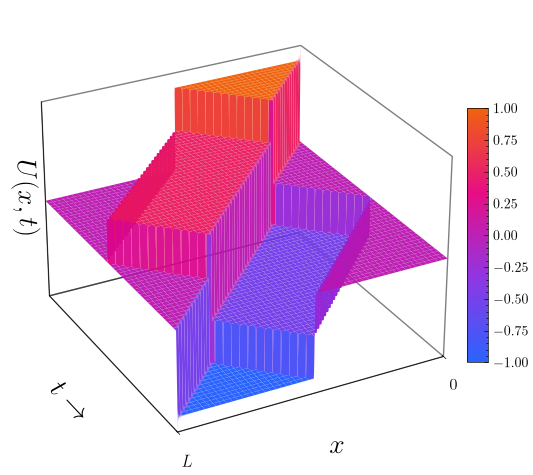

In [6]:
#%matplotlib widget
L = 1

x_min, x_max = 0, L
t_min, t_max = 0, 1
nx, nt = 1000, 1000  # grid resolution

c = 1 

def U(x, t):
    U = (2/np.pi)*sum((1/k)*(1-np.cos(k*np.pi/2))*np.sin(k*np.pi*x/L)*np.cos(k*np.pi*c*t/L) for k in range(1, 1000))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

u_min, u_max = float(np.nanmin(u)), float(np.nanmax(u))


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

ax.set_xticks([x_min, x_max])
ax.set_xticklabels(['$0$', '$L$'])
ax.tick_params(axis='x', length=4, width=0.8)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap=neon_cmap(), linewidth=0, antialiased=True, alpha=0.95
)

style_ax3d(
    ax, xlabel='$x$', ylabel='$t \\rightarrow$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

ax.zaxis.labelpad = -12

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

ax.view_init(elev=28, azim=62)

savefig(fig, "chap8sec8.4ex14.pdf", bbox_inches='tight', pad_inches=0.3)
plt.show()

Question 8.4.16

saved chap8sec8.4ex16.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\deqla\chap8\sec8.4\chap8sec8.4ex16.pdf


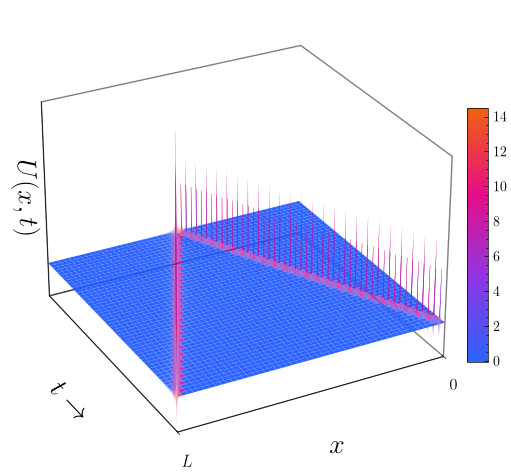

In [7]:
#%matplotlib widget
L = 2

x_min, x_max = 0, L
t_min, t_max = 0, 1
nx, nt = 1000, 1000  # grid resolution

c = 1 

def U(x, t):
    U = sum(np.sin(np.pi*(2*k+1)/(2*L))*np.sin(np.pi*(2*k+1)*x/(2*L))*np.cos(np.pi*(2*k+1)*c*t/(2*L)) for k in range(0, 1000))
    return U

# --- Build grid and Z ---
x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)
x, t = np.meshgrid(x, t)
u = U(x, t)

u_min, u_max = float(np.nanmin(u)), float(np.nanmax(u))


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.yaxis.set_major_locator(MaxNLocator(2))
ax.zaxis.set_major_locator(MaxNLocator(2))
ax.minorticks_off()

ax.set_xticks([x_min, x_max])
ax.set_xticklabels(['$0$', '$L$'])
ax.tick_params(axis='x', length=4, width=0.8)
ax.set_yticks([])
ax.set_zticks([])

surf = ax.plot_surface(
    x, t, u, cmap=neon_cmap(), linewidth=0, antialiased=True, alpha=0.95
)

style_ax3d(
    ax, xlabel='$x$', ylabel='$t \\rightarrow$', zlabel='$U(x, t)$',
    xlim=(x_min, x_max), ylim=(t_min, t_max), zlim=(u_min, u_max),
    label_fontsize=20,
    tick_fontsize=12
)

ax.zaxis.labelpad = -12

fig.colorbar(surf, ax=ax, shrink=0.55, aspect=12, pad=0)

ax.view_init(elev=28, azim=62)

savefig(fig, "chap8sec8.4ex16.pdf", bbox_inches='tight', pad_inches=0.3)
plt.show()